[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)]([https://drive.google.com/file/d/1O30n5DlO5uFKk1gZj28qKh0sIcm0ghLg/view?usp=drive_link])

# TRANSFER LEARNING

Authors: Joseph Hellerstein & Valentina Staneva & Claude

This notebook is built on these sources:

* [*Tensorflow Classification Tutorial*](https://www.tensorflow.org/tutorials/images/classification)

* [*Transfer Learning with VGG16 and Keras*](https://towardsdatascience.com/transfer-learning-with-vgg16-and-keras-50ea161580b4),  Medium Blog Post by Gabriel Cassimiro

* [*Tensorflow Transfer Learning Tutorial*](https://www.tensorflow.org/tutorials/images/transfer_learning)

*  https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

# Summary of Transfer Learning

Transfer learning is the practice of taking a model that was trained on one task and reusing it — fully or partially — as the starting point for a different task, rather than training from scratch.

### The Core Idea

When a CNN like VGG16 is trained on ImageNet, its convolutional layers learn general-purpose visual features that are useful far beyond ImageNet itself:

- **Early layers** learn low-level features: edges, corners, color gradients
- **Middle layers** learn mid-level features: textures, patterns, simple shapes
- **Later layers** learn high-level features: eyes, wheels, fur — things specific to the original task

These features turn out to be broadly useful for *any* image recognition task. Rather than relearning them from scratch, transfer learning lets you borrow them.
The term **base model** is used to refer to previously trained model that is reused with other tasks.


<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/transfer_learning.png" width="750">

### Why It Works Well

- **Less data needed**: the conv base already knows how to see; you only need enough data to teach the new head your specific classes
- **Faster training**: you're only updating a small fraction of parameters
- **Better results**: especially when your dataset is small, starting from strong pretrained weights almost always outperforms training from scratch

### Transfer Learning & Software Engineering

Transfer learning promotes reuse, reproducibility, and resource efficiency.

# Setup

Import TensorFlow and other necessary libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import tensorflow as tf
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image  # type: ignore
from tensorflow import keras # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.datasets import mnist # type: ignore
import tensorflow.keras.datasets as tfkds # type: ignore
import tensorflow_datasets as tfds # type: ignore
from tensorflow.keras.applications.vgg16 import VGG16 # type: ignore
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
from tensorflow.keras import layers, models # type: ignore
from typing import List, Callable

In [2]:
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())

torch


In [3]:
# Constants
DATA_DIR = ""
IMAGE_PATH_DCT = {}
NUM_EPOCH = 50  # Quick pass

# Helpers

In [4]:
(X_TRAIN, Y_TRAIN), (X_TEST, Y_TEST) = keras.datasets.fashion_mnist.load_data()
# Manually define Fashion MNIST labels as tfds.load caused an AttributeError.
LABELS = np.array(['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'])

## plotAccuracy

In [5]:
def plotAccuracy(history, history_fine=None):
    """
    Plots accuracy over the history.
    """
    plt.rcParams["figure.figsize"] = [10, 5]
    plt.rcParams["figure.autolayout"] = True
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(history.history['accuracy']) + 1)

    if history_fine is not None:
        acc += history_fine.history['accuracy']
        val_acc += history_fine.history['val_accuracy']
        epochs = range(1, len(history.history['loss'])+ len(history_fine.history['accuracy'])+1)
    # Accuracy
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy: Fine-tuned VGG')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)

## print_cosine_similarity, show_pair

In [6]:
def print_cosine_similarity(embedding_a, embedding_b):
  cos = cosine_similarity(embedding_a, embedding_b)
  # We do this to limit the number of decimals in the printed output
  result = f'Cosine similarity = {cos:.2f}'
  print(result)

def show_pair(imag_a, imag_b):
  plt.subplot(121)
  plt.imshow(np.array(imag_a))
  plt.axis("off")

  plt.subplot(122)
  plt.imshow(np.array(imag_b))
  plt.axis("off")

# Flowers data again

Data: 3,700 photos of flowers categorized as

```
  daisy
  dandelion
  roses
  sunflowers
  tulips
```

In [7]:
# Arranged in directories by class data_dir/flower_photo_extraced/daisy, ...
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
DATA_DIR = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
DATA_DIR = pathlib.Path(DATA_DIR).with_suffix('')
DATA_DIR = os.path.join(DATA_DIR, "flower_photos")
print(DATA_DIR)


/Users/jlheller/.keras/datasets/flower_photos_extracted/flower_photos


In [8]:
# Create training and test datasets
HEIGHT = 150
WIDTH = 150
train_ds, test_ds = tf.keras.utils.image_dataset_from_directory(
  DATA_DIR,
  validation_split=0.2,
  subset="both",
  labels="inferred",
  label_mode="categorical",
  seed=123,
  image_size=(HEIGHT, WIDTH),
)
# convert to numpy arrays
train_images, train_labels = zip(*list(train_ds.unbatch()))
train_images = np.array(train_images)
train_labels = np.array(train_labels)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.


# Embeddings

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/embedding_models.png" width="500">

*https://learnopencv.com/embedding-models-explained/

### What is an embedding?

In [9]:
if DATA_DIR == "":
    DATA_DIR = "/Users/jlheller/.keras/datasets/flower_photos_extracted/flower_photos"
classes = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
IMAGE_PATH_DCT = {}
for cls in classes:
    class_path = os.path.join(DATA_DIR, cls)  # type: ignore
    IMAGE_PATH_DCT[cls] = [os.path.join(class_path, f) for f in os.listdir(class_path)]

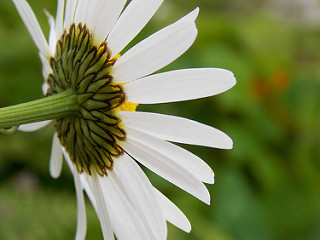

In [10]:
Image.open(IMAGE_PATH_DCT['daisy'][0])

In [11]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input  # type: ignore
from tensorflow.keras.preprocessing.image import img_to_array  # type: ignore

# Load the pretrained model (embeddings only, no top classification layer)
model = ResNet50(weights="imagenet", include_top=False, pooling="avg")

# Function to extract embeddings from an image
def extract_embedding(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))  # Keras models expect a fixed input size
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis=0)  # Add batch dimension
    image_array = preprocess_input(image_array)  # Applies ImageNet normalization
    embedding = model.predict(image_array, verbose=0)
    return embedding.squeeze()

# Example usage
embedding = extract_embedding(IMAGE_PATH_DCT['daisy'][0])
print(embedding.shape)
print("\n\nFirst 10 elements of the embedding vector:")
embedding[:10]

(2048,)


First 10 elements of the embedding vector:


array([3.5319302 , 0.12086089, 0.41442677, 0.15401031, 0.22477637,
       0.6421027 , 0.52231425, 0.0102356 , 0.13792022, 0.01764445],
      dtype=float32)

## Cosine similarity

We compare objects by the closeness of their vector representations.
The **cosine similarity metric** is computed as the cosine of the angle between these two vectors.

$$ \text{Cosine Similarity} = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}} $$



where:
- $ A $ and $ B $ are the feature vectors of the two images.
- $ A \cdot B $ is the dot product of vectors $ A $ and $ B $.
- $ \|A\| $ and $ \|B\| $ are the magnitudes (or norms) of vectors $ A $ and $ B $.

The result is a value between -1 and 1 that we can interpret easily:
- **1 indicates the vectors are identical:** 0 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [1, 1, 1]`.
- **0 indicates orthogonality: no similarity**, 90 degree angle between the vectors, the most extreme case of dissimilarity, like a pair of vectors comprised of `vector_a = [1, 1, 1]`, `vector_b = [0, 0, 0]`  .
- **-1 indicates signed opposite vectors:** 180 degree angle between the vectors, like a pair of vectors comprised of `vector_a = [5, 5, 5]`, `vector_b = [-5, -5, -5]`.

![](https://github.com/andandandand/image-dataset-curation/blob/main/images/orthogonal.png?raw=true)


Notice that the cosine similarity will output values between 0 and 1 when the input vectors are positive. This is how we most commonly use it to compare embeddings. It's advantageous that it's bounded between these two values for similar and  It's also important to know that there are many other ways that we can use to compute distance between vectors, with the [Euclidean distance](https://en.wikipedia.org/wiki/Euclidean_distance) being an alternative. The cosine similarity is strongly preferred over the Euclidean distance on many information-retrieval tasks as it is indifferent to the magnitude of the embedding vectors.

## Exploring cosine similarity

Cosine similarity = 0.44


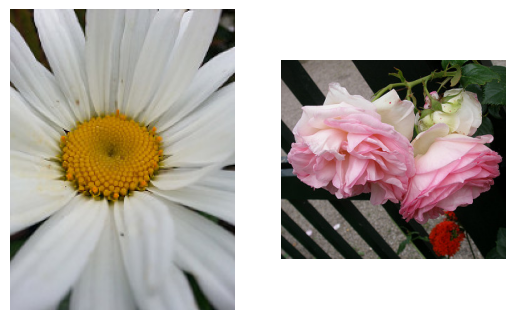

In [12]:
left_flower = 'daisy'  # daisy, dandelion, roses, sunflowers, tulips
right_flower = 'roses'  # daisy, dandelion, roses, sunflowers, tulips

def get_random_image_from_class(cls):
    idx = np.random.randint(0, len(IMAGE_PATH_DCT[cls]))
    image_path = IMAGE_PATH_DCT[cls][idx]
    return image_path, extract_embedding(image_path)
def print_cosine_similarity(embedding_a, embedding_b):
    embedding_ap = embedding_a.reshape(1, -1)
    embedding_bp = embedding_b.reshape(1, -1)
    cos = cosine_similarity(embedding_ap, embedding_bp)[0, 0]
    result = f'Cosine similarity = {cos:.2f}'
    print(result)
##
a_image_path, a_embedding = get_random_image_from_class(left_flower)
b_image_path, b_embedding = get_random_image_from_class(right_flower)
print_cosine_similarity(a_embedding, b_embedding)
show_pair(Image.open(a_image_path), Image.open(b_image_path))

Explore cosine similarity by changing the class of flowers compared.

## Manipulating embeddings

Sometimes arithemtic operations on the embedding vectors has semantics.

Consider the following vector equation

    QUEEN = KING - MAN + WOMAN

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/king_queen.png" width="350">

*https://www.searchenginejournal.com/bert-explained-what-you-need-to-know-about-googles-new-algorithm/337247/

# Imagenet Model (VGG16)

VGG16 is a classic deep convolutional neural network developed by the Visual Geometry Group at Oxford University in 2014, and published in the paper *"Very Deep Convolutional Networks for Large-Scale Image Recognition"* by Simonyan and Zisserma. It was a top performer in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2014.

### Design Philosophy

The key insight of VGG16 was simplicity and depth: instead of using large kernels (like the 11×11 and 5×5 filters in earlier AlexNet), it stacks many small **3×3 Conv2D layers** with `padding='same'`, which:
- Keeps the architecture uniform and easy to reason about
- Uses fewer parameters than larger kernels while achieving the same receptive field
- Adds more non-linearity (more ReLU activations) which increases expressive power

The "16" in VGG16 refers to the 16 layers that have trainable parameters (13 conv + 3 dense).

<img src="https://raw.githubusercontent.com/joseph-hellerstein/ai_in_practice/main/images/vgg16.png" width="750">

### Architecture

| Block | Layers | Output Shape |
|---|---|---|
| Input | — | `(224, 224, 3)` |
| Block 1 | Conv2D(64) × 2, MaxPool | `(112, 112, 64)` |
| Block 2 | Conv2D(128) × 2, MaxPool | `(56, 56, 128)` |
| Block 3 | Conv2D(256) × 3, MaxPool | `(28, 28, 256)` |
| Block 4 | Conv2D(512) × 3, MaxPool | `(14, 14, 512)` |
| Block 5 | Conv2D(512) × 3, MaxPool | `(7, 7, 512)` |
| — | Flatten | `(25088,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(4096), ReLU | `(4096,)` |
| — | Dense(1000), Softmax | `(1000,)` |

All Conv2D layers use `kernel_size=3`, `padding='same'`, and `activation='relu'`. All MaxPooling layers use `pool_size=(2,2)`, which is why spatial dims halve at each block. The final Dense(1000) corresponds to the 1000 ImageNet classes.

### Parameter Count

VGG16 has approximately **138 million parameters**, which was large even by 2014 standards. The striking thing is how lopsided the distribution is:

| Section | Params | % of total |
|---|---|---|
| All 13 Conv2D layers | ~15M | ~11% |
| Dense(4096) × 2 + Dense(1000) | ~123M | ~89% |

The two Dense(4096) layers alone account for the vast majority of parameters, which is why modern architectures (ResNet, EfficientNet, etc.) tend to use Global Average Pooling before the classifier head instead of Flatten → Dense, dramatically cutting parameter counts.

### Loading VGG16 in Keras

Keras includes VGG16 as a built-in model, optionally with ImageNet pretrained weights:

```python

model = VGG16(
    weights='imagenet',   # or None for random init
    include_top=True,     # False drops the Dense layers, useful for transfer learning
    input_shape=(224, 224, 3)
)

model.summary()
```

### Strengths and Weaknesses

| Strengths | Weaknesses |
|---|---|
| Simple, uniform architecture — easy to understand | 138M params — very heavy to train and store |
| Strong pretrained features, great for transfer learning | Slow inference compared to modern nets |
| Influenced almost all subsequent CNN designs | No skip connections — deep gradient flow can be difficult |
| Well studied and documented | Largely superseded by ResNet, EfficientNet, etc. |

Despite its age, VGG16 remains widely used as a **feature extractor** in transfer learning, since its convolutional blocks produce rich, general-purpose image features that transfer well to new tasks.

# Transfer Learning Using VGG16

Convolutional Neural Networks can be good feature extractors, i.e. a model trained on one dataset can turn out to be good at extracting useful features from another dataset. This allows deep learning methods to leverage large training sets and be able to generalize to situations where training data can be scarce.

* predict with a pretrained model on new data (zero-shot learning)
* extract features with a pretrained model and use them to train a shallow classifier on new data
* fine-tune the trained model to the new data by training with a small learning rate
* retrain the full model using the pre-trained model weights as initializers

As usual, we will have to evaluate the performance!

![TransferLearning](https://drive.google.com/uc?export=view&id=1QF9-eDrTkMouYJdU4k1qCklT3pLCI61u)

image src = https://www.slideshare.net/xavigiro/transfer-learning-d2l4-insightdcu-machine-learning-workshop-2017

<img src="https://i.stack.imgur.com/RTKux.png" width="750">

## Basic procedure

1. Load and initialize a pretrained model: (a)removing the top layer and (b) freezing the weights of the pretrained model
3. Shape the data for the pretrained model
4. Build the new model adding a new top layer appropriate for the data and task
5. Train the model
6. Evaluate the model

### 1. Load and initialize a pretrained model

In [13]:
# Load the model without the top layer
pretrained_model = VGG16(weights="imagenet", include_top=False, input_shape=(HEIGHT, WIDTH, 3))
# Freeze the model weights
pretrained_model.trainable = False ## Not trainable weights

In [14]:
pretrained_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### 2. Shape the data for the base model

Pretrained models have certain expectations of how the data should look like so that it can be used in the model. They have a corresponding [`preprocess_input`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/vgg16/preprocess_input) model. Make sure you read on the operations in the preprocessing so that it makes sense for your data.

In [15]:
from tensorflow.keras.applications.vgg16 import preprocess_input
preprocess_input(train_images.copy()).shape

(2936, 150, 150, 3)

**Warning!** The `preprocess_input` function changes the input **in-place** hence we need to pass a copy of the images.  

### 3. Build the new model

In [16]:
flatten_layer = layers.Flatten()
dense_layer_1 = layers.Dense(128, activation='relu')
prediction_layer = layers.Dense(5, activation='softmax')


model = models.Sequential([
    pretrained_model,
    flatten_layer,
    dense_layer_1,
    prediction_layer
])

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,037 (60.14 MB)

 Trainable params: 1,049,349 (4.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Notes
* ``flatten_1`` is dimensioned so that $ 8192 = 4 \times 4 \times 512$
* ``dense_2`` corresponds to our 5 classes

### 4. Train the new model

We train the model only for the new layers that we added.

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [19]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
history = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=NUM_EPOCH,
  batch_size=32,
  callbacks=[es]
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.6529 - loss: 4.7870 - val_accuracy: 0.7619 - val_loss: 3.2973
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.8062 - loss: 2.7309 - val_accuracy: 0.7687 - val_loss: 3.2113
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8109 - loss: 2.6878 - val_accuracy: 0.7721 - val_loss: 3.3315
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.8573 - loss: 1.9873 - val_accuracy: 0.7636 - val_loss: 3.3872
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.8612 - loss: 1.9029 - val_accuracy: 0.7840 - val_loss: 3.0804
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8807 - loss: 1.6579 - val_accuracy: 0.7891 - val_loss: 2.9672
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.8952 - loss: 1.5227 - val_accuracy: 0.8078 - val_loss: 2.6977
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.9097 - loss: 1.3431 - val_accuracy: 0.

### 5. Evalute the model

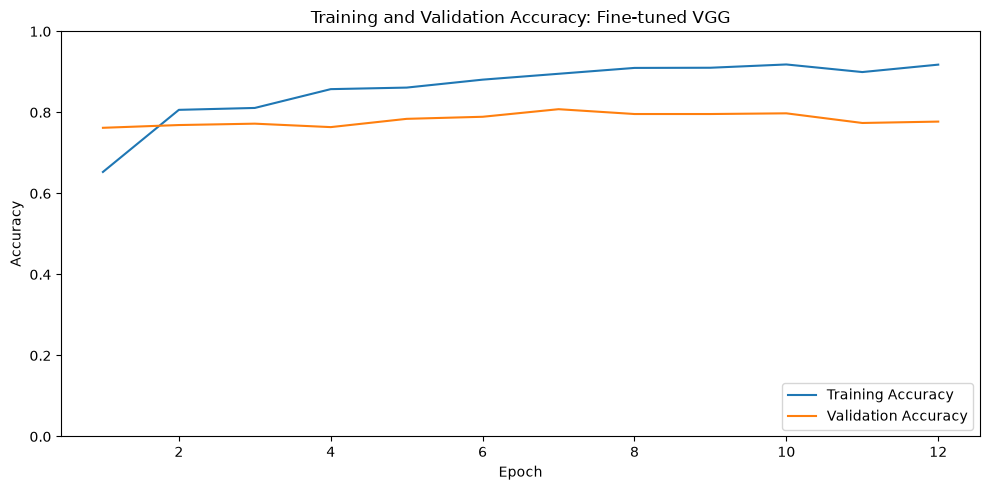

In [20]:
plotAccuracy(history)  # type: ignore

## Fine-Tune Pretrained Weights

In fine-tuning, we adjust the weights of the base model. This typically is much less time consuming than a full training since the pretrained weights are likely close to the weights after fine-tuning.

Fine Tuning:
* Set the pretrained model to trainable (or some of its layers)
* Compile the model again
* Retrain with a small learning rate (0.0001)


In [21]:
pretrained_model.trainable = True

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,037 (60.14 MB)

 Trainable params: 15,764,037 (60.14 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
%%time
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=5,  restore_best_weights=True)
history_fine = model.fit(
  preprocess_input(train_images.copy()),
  train_labels,
  validation_split=0.2,
  epochs=NUM_EPOCH,
  batch_size=32,
  callbacks=[es]
)

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 610ms/step - accuracy: 0.8897 - loss: 1.5829 - val_accuracy: 0.7993 - val_loss: 2.8194
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 609ms/step - accuracy: 0.8957 - loss: 1.4968 - val_accuracy: 0.7704 - val_loss: 3.3984
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 610ms/step - accuracy: 0.9093 - loss: 1.3061 - val_accuracy: 0.8010 - val_loss: 2.8521
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 610ms/step - accuracy: 0.9101 - loss: 1.2556 - val_accuracy: 0.8418 - val_loss: 2.2328
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 612ms/step - accuracy: 0.9374 - loss: 0.8446 - val_accuracy: 0.8333 - val_loss: 2.4443
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 610ms/step - accuracy: 0.9391 - loss: 0.8704 - val_accuracy: 0.8248 - val_loss: 2.2648
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 610ms/step - accuracy: 0.9382 - loss: 0.8812 - val_accuracy: 0.8197 - val_loss: 2.4727
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 45s 611ms/step - accuracy: 0.9387 - loss: 0.8495 - val_accu

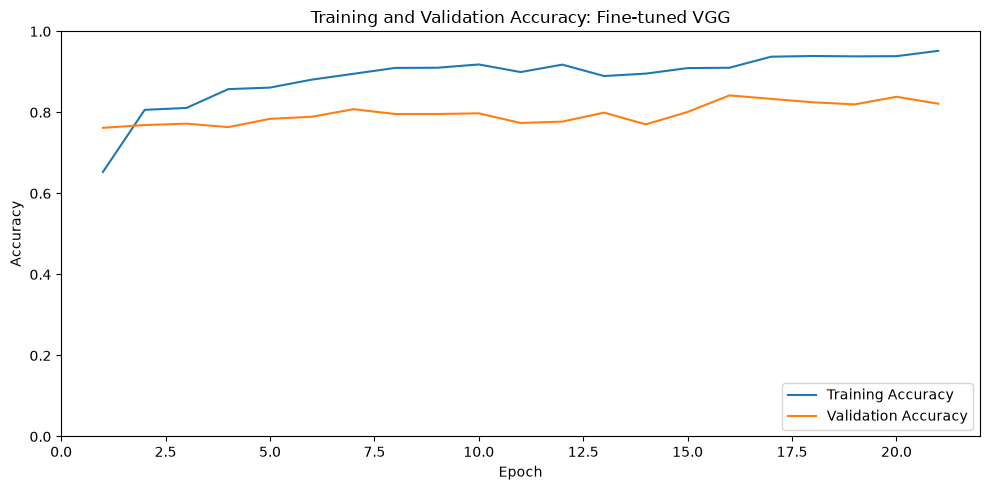

In [25]:
plotAccuracy(history, history_fine)  # type: ignore

**Exercise:** Retrain full model starting from the imagenet weights (making all weights trainable).

**Exercise:** Retrain the last 10 layers of the pretrained model + the top layer.
**Hint:** Use a loop to unfreeze layers.

Pretrained models can be found:
* within the [keras library](https://keras.io/api/applications/)
* on [tensorflow(kaggle) hub](https://www.tensorflow.org/hub)
* [HuggingFace](https://huggingface.co/models)
* domain-specific challenges
* colleagues


# Selecting the Base Model

There are a large number of potentially relevant models that can be found in
``keras.applications`` and Hugging Face.

| Model | Description |
|---|---|
| **Xception** | Depthwise separable convolutions replace Inception modules; efficient and accurate. |
| **VGG16 / VGG19** | Simple, deep stacks of 3x3 convolutions; large parameter count, classic baseline model. |
| **ResNet50 / ResNet101 / ResNet152** | Introduces residual (skip) connections to enable training very deep networks. |
| **ResNet50V2 / ResNet101V2 / ResNet152V2** | Improved ResNet variants with pre-activation batch normalization for better gradient flow. |
| **InceptionV3** | Uses parallel convolutions of different sizes (Inception modules) for multi-scale feature extraction. |
| **InceptionResNetV2** | Combines Inception modules with residual connections for faster convergence. |
| **MobileNet** | Lightweight model using depthwise separable convolutions, designed for mobile/embedded devices. |
| **MobileNetV2** | Adds inverted residuals and linear bottlenecks to MobileNet for improved efficiency. |
| **MobileNetV3Small / MobileNetV3Large** | Uses neural architecture search (NAS) and squeeze-and-excite blocks for further mobile optimization. |
| **DenseNet121 / DenseNet169 / DenseNet201** | Each layer connects to every other layer in a feed-forward fashion, improving feature reuse and gradient flow. |
| **NASNetMobile / NASNetLarge** | Architecture discovered via neural architecture search (NAS) rather than manual design. |
| **EfficientNetB0–B7** | Uses compound scaling (depth, width, resolution) for a strong accuracy/efficiency tradeoff. |
| **EfficientNetV2B0–B3, S/M/L** | Improved EfficientNet with faster training and better parameter efficiency. |
| **ConvNeXtTiny/Small/Base/Large/XLarge** | Modernized pure ConvNet architecture inspired by design choices from Vision Transformers. |

Some hints for selecting an appropriate base model.
* Look at the shape of the input data. If inputs are much bigger than your data, inference may be very inefficient. If inputs are much smaller, than you may lose key characteristics when you reshape the data.
* See what data the base model is trained on. Is it similar to your data?
* Select a few candidates and try transfer learning on each.

### Model comparisons

| Model | Train Time (sec) | Accuracy |
|-------|------------:|----------:|
| VGG16 | 150 | 0.34 |
| MovileNetV2 | 360 | 0.13 |
| EfficientNetV2L | 1,600 | 0.07 |
| MobileNetV2 | 355 | 0.14 |
| EfficientNetB7 | 1,305 | 0.07 |
| DenseNet169 | 1,065 | 0.38 |
| NASNNetLarge | 1,104 | 0.04 |
| ConvNeXtLarge | 490 | 0.08 |
| ResNet50V2 | 344 | 0.16 |         

# Exercise

* Do transfer learning and fine tuning using ResNet50V2 on the flowers dataset.

# RECAP

* Transfer learning provides a way leverage a previously trained network, referred to as the base network.
* The approach requires
    * reshaping the input data
    * delete the "top" layer of the previously trained network
    * add layers specific to your task.
* Fine tuning may be required to make the new network perform well.
* Some exploration may be required to select the base network.

# Notes
1. Care on switch to text data set from images
3. Relate to a plant identifying application
5. Describe tokens